In [1]:
import math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import scipy.sparse as sp
import os 
from reaction_diffusion.routines.tomo_fusion.tools import plotting_fcts as tomo_plots
import pandas as pd

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

from helpers import *

device: cuda


In [2]:
# total time estimation
num_test_samples=1000
num_posterior_samples=100
time_per_sample=10
noise_levels=3
procedures=2
num_diagnostics = 2
total_time = num_diagnostics * num_test_samples*time_per_sample*noise_levels*procedures
print("Total time: ", total_time/(60*60), " hours")

Total time:  33.333333333333336  hours


In [3]:
# check hyperparameter tuning results
#csv_name = f"metrics_diffusion_sxr_{sigma_y_tomo}_zeta{zeta}_lambda{lambda_}.csv"

noise_levels = [0.05, 0.25, 0.5]
lambda_values  = [50, 100, 200, 300, 400, 500]
zeta_values = [0.2, 0.4, 0.6, 0.8, 1.0]

results = []
for noise in noise_levels:
    for zeta in zeta_values:
        for lambda_ in lambda_values:
            csv_name = f"metrics_csv/metrics_diffusion_sxr_{noise}_zeta{zeta}_lambda{lambda_}.csv"
            if os.path.exists(csv_name):
                df = pd.read_csv(csv_name)
                df["noise"] = noise
                df["zeta"] = zeta
                df["lambda"] = lambda_
                results.append(df)
            else:
                print(f"File {csv_name} not found.")

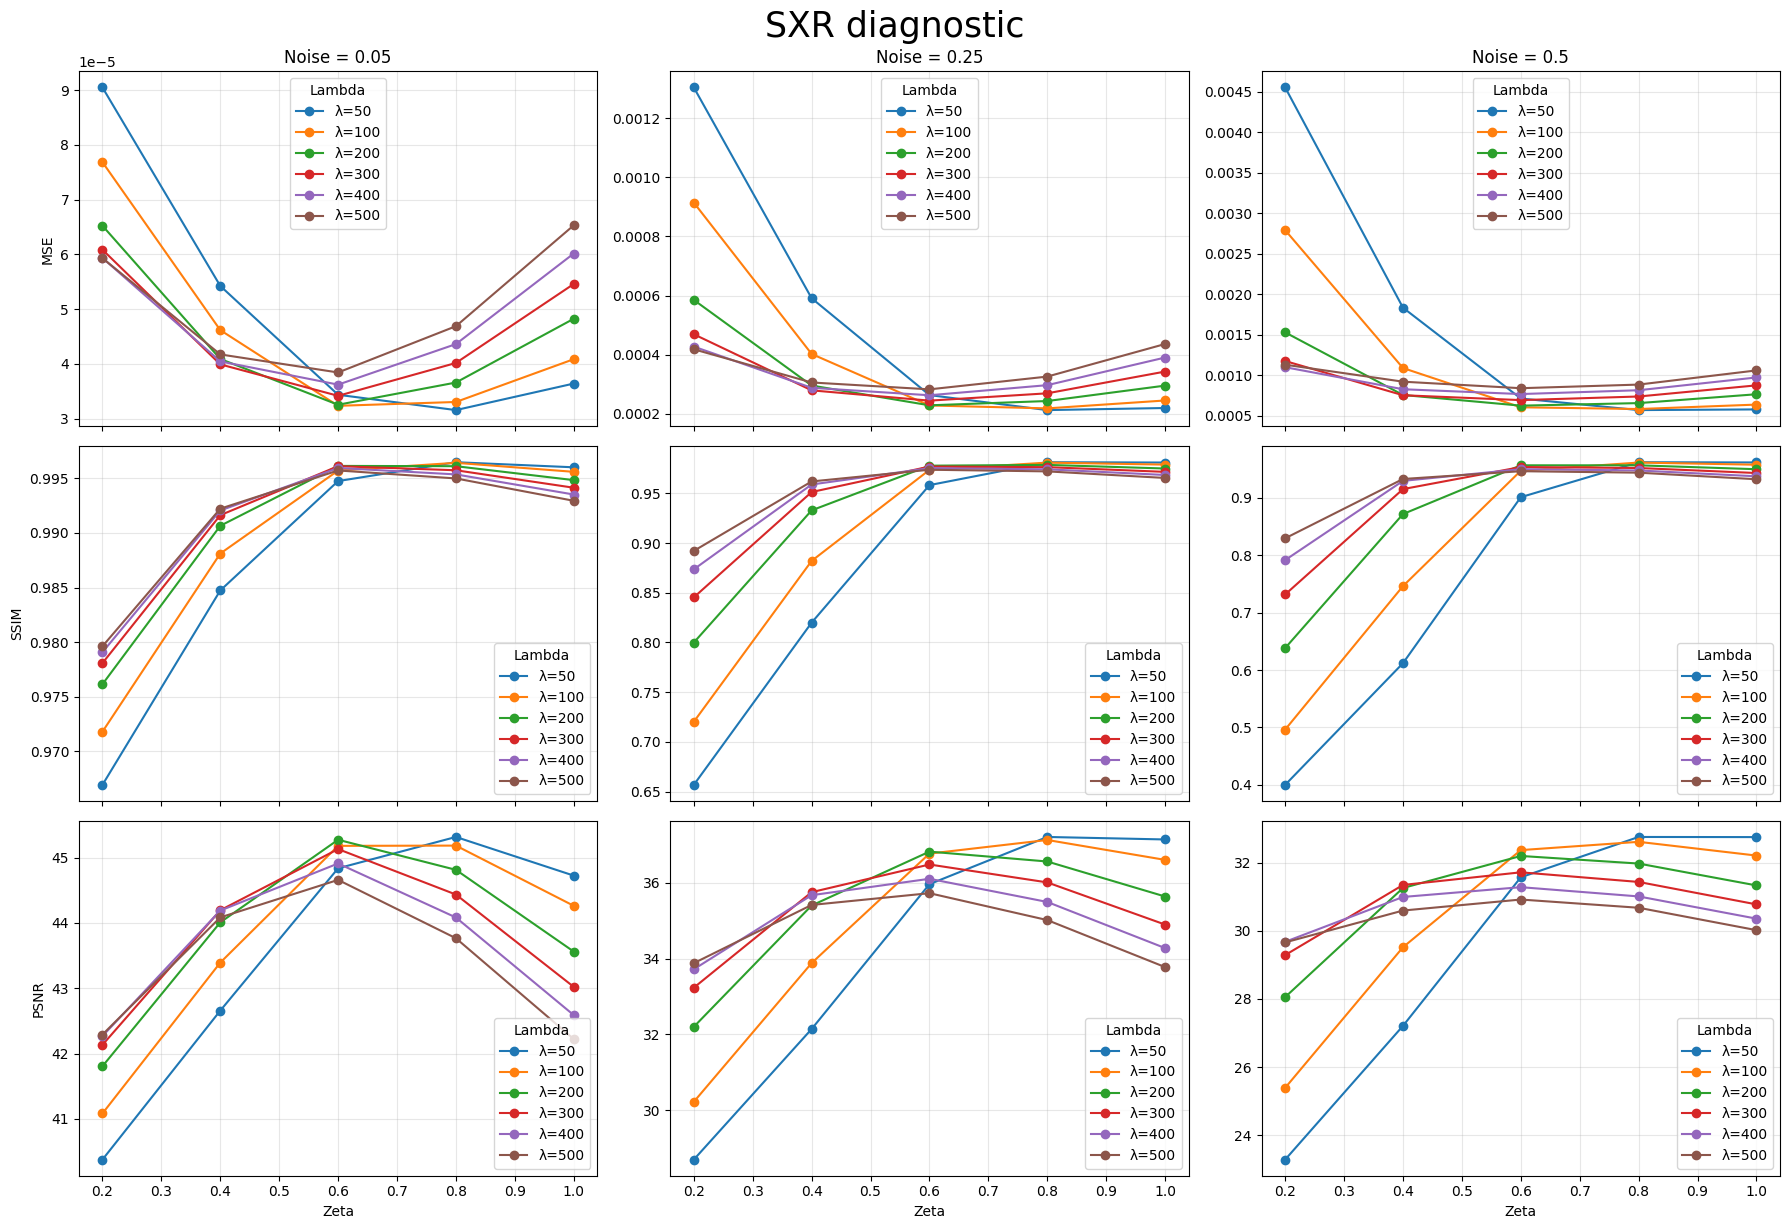

In [10]:
metrics = ["mse", "ssim", "psnr"]
metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}

df_all = pd.concat(results, ignore_index=True)
df_avg = df_all.groupby(["noise", "zeta", "lambda"], as_index=False)[metrics].mean()

fig, ax = plt.subplots(3, 3, figsize=(18, 12), sharex=True)

for r, metric in enumerate(metrics):
    for c, noise in enumerate(noise_levels):
        a = ax[r, c]
        df_noise = df_avg[df_avg["noise"] == noise] 

        for lambda_ in lambda_values:
            df_curve = df_noise[df_noise["lambda"] == lambda_].sort_values("zeta")
            a.plot(df_curve["zeta"], df_curve[metric], marker="o", label=f"λ={lambda_}")

        if r == 0:
            a.set_title(f"Noise = {noise}")
        if c == 0:
            a.set_ylabel(metric_labels[metric])
        if r == 2:
            a.set_xlabel("Zeta")

        a.grid(alpha=0.3)

# keep legends only on the rightmost column to reduce clutter
for r in range(3):
    for i in range(3):
        if r==0:
            ax[r, i].legend(title="Lambda", loc="upper center")
        else:
            ax[r, i].legend(title="Lambda", loc="lower right")

plt.tight_layout()
plt.suptitle("SXR diagnostic", y=1.02, fontsize=25)
plt.savefig("sxr_hyperparameter_tuning_results.png", dpi=300)
plt.show()



In [13]:
# check hyperparameter tuning results
#csv_name = f"metrics_diffusion_sxr_{sigma_y_tomo}_zeta{zeta}_lambda{lambda_}.csv"

noise_levels = [0.1, 0.5, 1.0]
lambda_values  = [50, 100, 200, 300, 400, 500]
zeta_values = [0.2, 0.4, 0.6, 0.8, 1.0]

results = []
for noise in noise_levels:
    for zeta in zeta_values:
        for lambda_ in lambda_values:
            csv_name = f"metrics_csv/metrics_diffusion_dmpx_{noise}_zeta{zeta}_lambda{lambda_}.csv"
            if os.path.exists(csv_name):
                df = pd.read_csv(csv_name)
                df["noise"] = noise
                df["zeta"] = zeta
                df["lambda"] = lambda_
                results.append(df)
            else:
                print(f"File {csv_name} not found.")

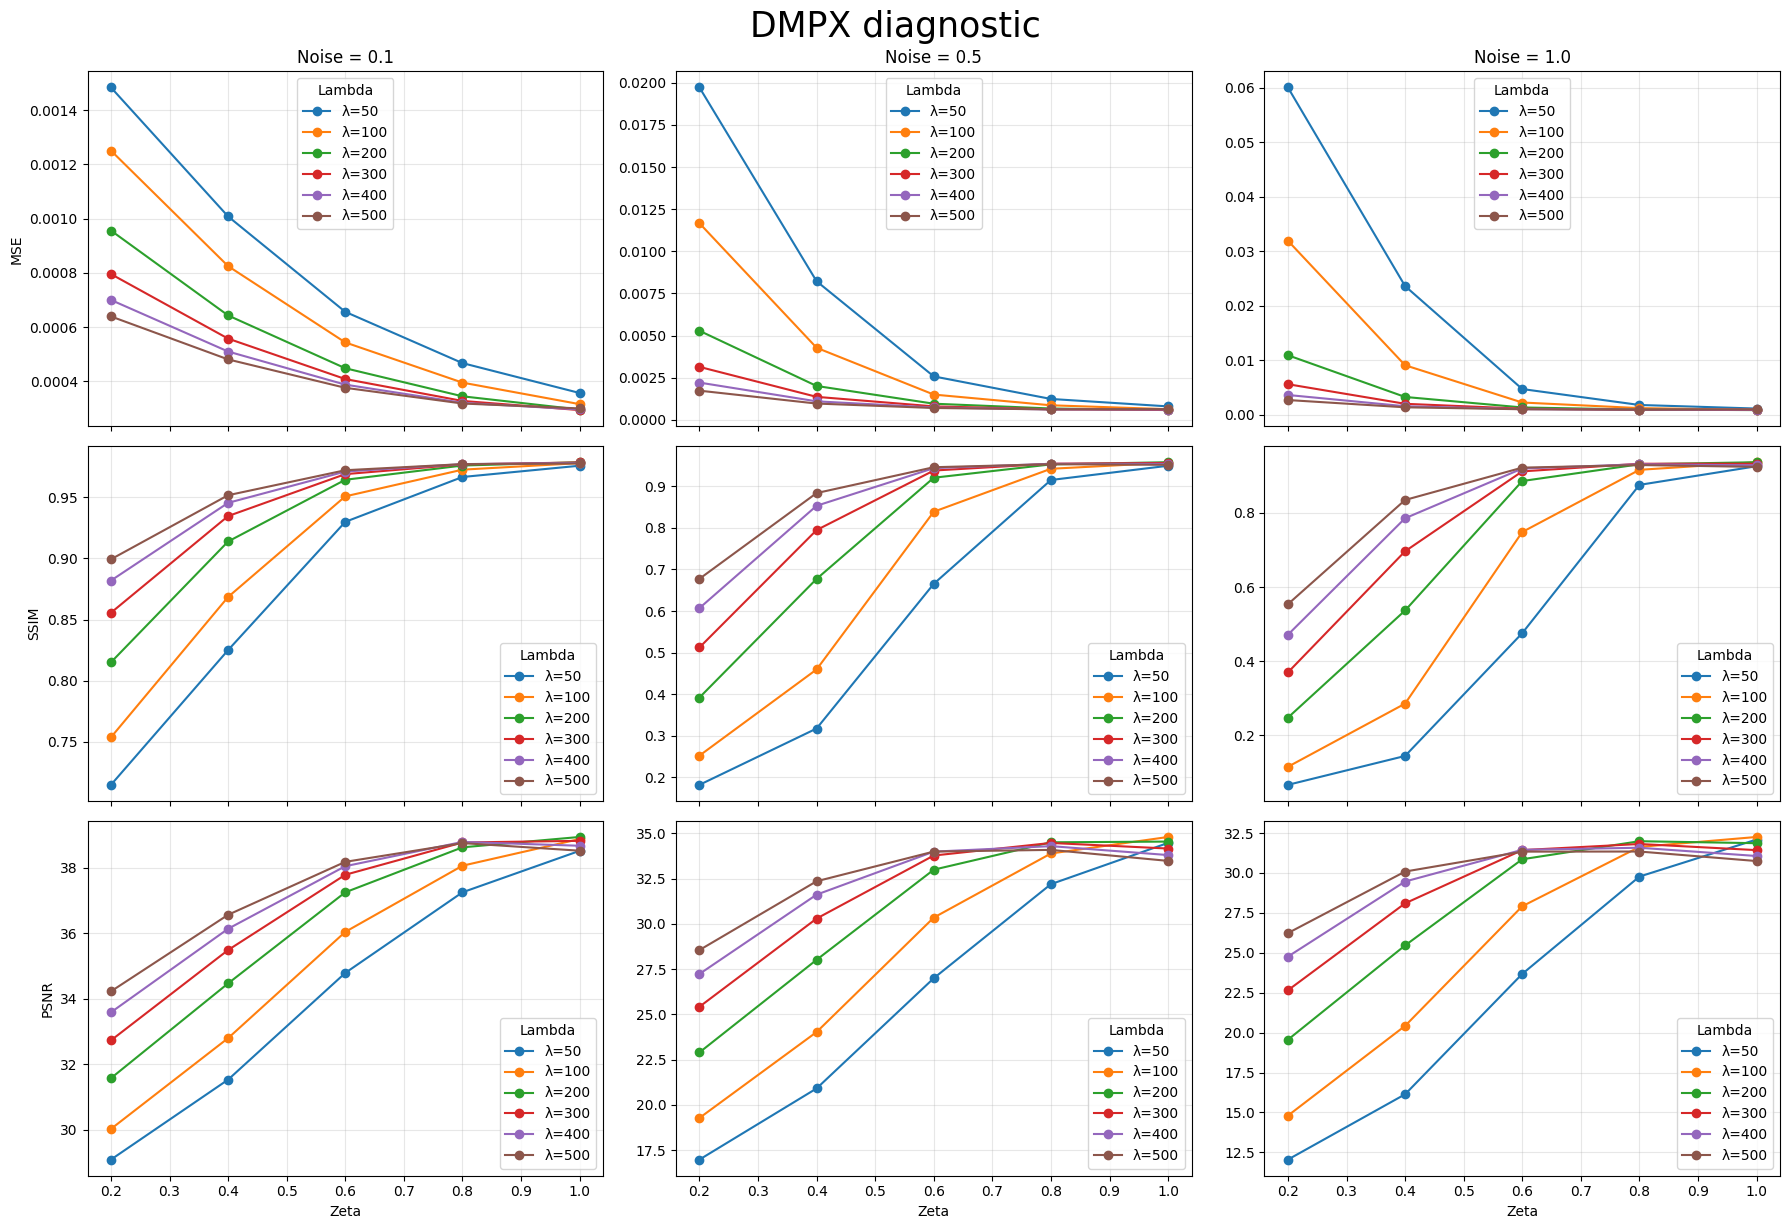

In [14]:
metrics = ["mse", "ssim", "psnr"]
metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}

df_all = pd.concat(results, ignore_index=True)
df_avg = df_all.groupby(["noise", "zeta", "lambda"], as_index=False)[metrics].mean()

fig, ax = plt.subplots(3, 3, figsize=(18, 12), sharex=True)

for r, metric in enumerate(metrics):
    for c, noise in enumerate(noise_levels):
        a = ax[r, c]
        df_noise = df_avg[df_avg["noise"] == noise] 

        for lambda_ in lambda_values:
            df_curve = df_noise[df_noise["lambda"] == lambda_].sort_values("zeta")
            a.plot(df_curve["zeta"], df_curve[metric], marker="o", label=f"λ={lambda_}")

        if r == 0:
            a.set_title(f"Noise = {noise}")
        if c == 0:
            a.set_ylabel(metric_labels[metric])
        if r == 2:
            a.set_xlabel("Zeta")

        a.grid(alpha=0.3)

# keep legends only on the rightmost column to reduce clutter
for r in range(3):
    for i in range(3):
        if r==0:
            ax[r, i].legend(title="Lambda", loc="upper center")
        else:
            ax[r, i].legend(title="Lambda", loc="lower right")

plt.tight_layout()
plt.suptitle("DMPX diagnostic", y=1.02, fontsize=25)
plt.savefig("dmpx_hyperparameter_tuning_results.png", dpi=300)
plt.show()



In [15]:
df_avg

,noise,zeta,lambda,mse,ssim,psnr
0,0.1,0.2,50,0.001484,0.714917,29.085537
1,0.1,0.2,100,0.001251,0.753756,30.021848
2,0.1,0.2,200,0.000956,0.815054,31.572405
3,0.1,0.2,300,0.000796,0.855559,32.727648
4,0.1,0.2,400,0.000700,0.881852,33.584745
...,...,...,...,...,...,...
85,1.0,1.0,100,0.000930,0.936842,32.255774
86,1.0,1.0,200,0.000879,0.936809,31.865474
87,1.0,1.0,300,0.000918,0.932691,31.431218
88,1.0,1.0,400,0.000971,0.928366,31.063709


In [18]:
df_avg[df_avg["noise"] == 1.0]

,noise,zeta,lambda,mse,ssim,psnr
60,1.0,0.2,50,0.060037,0.066283,12.046017
61,1.0,0.2,100,0.031927,0.115037,14.799150
62,1.0,0.2,200,0.010934,0.247642,19.555626
63,1.0,0.2,300,0.005625,0.369690,22.651650
64,1.0,0.2,400,0.003648,0.471368,24.761866
65,1.0,0.2,500,0.002723,0.553711,26.234084
66,1.0,0.4,50,0.023620,0.144221,16.136539
67,1.0,0.4,100,0.009102,0.285431,20.421484
68,1.0,0.4,200,0.003287,0.536749,25.460892
69,1.0,0.4,300,0.002033,0.696516,28.098433


# Check phantom analysis results

In [2]:
# check sxr phantom analysis results
#csv_name = f"metrics_diffusion_sxr_{sigma_y_tomo}_zeta{zeta}_lambda{lambda_}.csv"

noise_levels = [0.05, 0.25, 0.5]

results = []
for noise in noise_levels:
    csv_name = f"metrics_csv_phantom_analysis/metrics_diffusion_sxr_{noise}_false.csv"
    if os.path.exists(csv_name):
        df = pd.read_csv(csv_name)
        df["noise"] = noise
        results.append(df)
    else:
        print(f"File {csv_name} not found.")

In [3]:
len(results)

3

In [25]:
# Average metrics for the first noise-level entry (0.05)
df_noise = results[0]  # corresponds to noise level 0.05

metrics = ["mse", "ssim", "psnr"]
metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}
avg_vals = df_noise[metrics].mean()


for m in metrics:
    print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

MSE: 0.000026 +- 0.0001
SSIM: 0.996104 +- 0.0074
PSNR: 47.074031 +- 3.1666


In [13]:
df_noise[metrics].median()

mse      0.000096
ssim     0.988199
psnr    40.101801
dtype: float64

In [11]:
df_noise[metrics].quantile([0.99])

,mse,ssim,psnr
0.99,0.000145,0.999132,53.418525


In [22]:
results[0].keys()

Index(['sample_idx', 'psnr', 'ssim', 'mse', 'post_std_mean', 'sigma_used',
       'alpha', 'scaling', 'noise'],
      dtype='str')

In [24]:
results[0]["post_std_mean"][0]

np.float64(0.0068165860138833)